# onet_pilot_walkthrough_v3

## Perubahan pada versi v3

Perubahan dari v2: seluruh output penting menampilkan nama occupation, nama kompetensi, dan deskripsi kompetensi bersama kode teknis agar hasil mudah diinterpretasikan.

Kode dan hasil pada versi ini mengikuti tujuan pilot yang sama.

# Notebook Belajar: melihat nama, bukan hanya kode

Notebook ini menampilkan nama occupation dan nama kompetensi di setiap hasil. Kode O*NET tetap ditampilkan sebagai ID untuk penelusuran, tetapi bukan satu-satunya informasi yang harus dibaca.

## Cara membaca identitas data

- **Occupation** adalah nama pekerjaan, misalnya *Data Scientists*.
- **O*NET-SOC Code** adalah ID unik pekerjaan tersebut, misalnya `15-2051.00`.
- **Element** adalah satu kompetensi atau pengetahuan, misalnya *Reading Comprehension*.
- **Element ID** adalah ID unik elemen tersebut, misalnya `2.A.1.a`.
- **Importance** adalah seberapa penting elemen itu untuk occupation.
- **IM** berarti skala Importance; hanya IM yang dipakai untuk matriks utama.

Jadi, kode dipakai agar data tidak ambigu, sedangkan nama dan deskripsi dipakai agar manusia dapat menginterpretasikan hasil.

In [1]:
from pathlib import Path
import os, sys, json
import numpy as np
import pandas as pd
from IPython.display import display, Markdown

ROOT = Path.cwd()
if not (ROOT / 'src').exists(): ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
os.environ['HF_HUB_OFFLINE'] = '1'
from src.pipeline_v2 import DOMAINS, EXPECTED, prepare, matrices, similarity, embedding_similarity, related_metrics

RAW = ROOT / 'data' / 'raw'
CONFIG = json.loads((ROOT / 'config' / 'occupations.json').read_text(encoding='utf-8'))
occupations = pd.read_csv(RAW / 'occupation_data.csv')
content = pd.read_csv(RAW / 'content_model_reference.csv')
related = pd.read_csv(RAW / 'related_occupations.csv')
ratings = {domain: pd.read_csv(RAW / filename) for domain, filename in DOMAINS.items()}

occupation_names = occupations.set_index('O*NET-SOC Code')['Title'].to_dict()
element_names = content.set_index('Element ID')['Element Name'].fillna('').to_dict()
element_descriptions = content.set_index('Element ID')['Description'].fillna('').to_dict()
FOCUS = CONFIG['core'] + CONFIG['sensitivity']

def occupation_label(code):
    return f"{occupation_names.get(code, 'Nama tidak ditemukan')} [{code}]"

def element_label(code):
    return f"{element_names.get(code, 'Nama tidak ditemukan')} [{code}]"

def label_matrix(matrix):
    result = matrix.copy()
    result.index = [occupation_label(code) for code in result.index]
    result.index.name = 'occupation (nama [kode])'
    result.columns = [element_label(code) for code in result.columns]
    return result

focus_table = pd.DataFrame({'occupation': [occupation_names.get(x, 'Nama tidak ditemukan') for x in FOCUS], 'O*NET-SOC Code': FOCUS, 'peran': ['core pilot' if x in CONFIG['core'] else 'sensitivity analysis' for x in FOCUS]})
display(Markdown('## Occupation fokus'))
display(focus_table)

## Occupation fokus

,occupation,O*NET-SOC Code,peran
0,Data Scientists,15-2051.00,core pilot
1,Business Intelligence Analysts,15-2051.01,core pilot
2,Database Administrators,15-1242.00,core pilot
3,Database Architects,15-1243.00,core pilot
4,Data Warehousing Specialists,15-1243.01,core pilot
5,Operations Research Analysts,15-2031.00,core pilot
6,Statisticians,15-2041.00,core pilot
7,Clinical Data Managers,15-2051.02,sensitivity analysis


## 1. Mengenali tujuh file O*NET

Tiga file pertama berisi rating kompetensi. `occupation_data.csv` menerjemahkan kode occupation menjadi nama pekerjaan. `content_model_reference.csv` menerjemahkan Element ID menjadi nama dan deskripsi kompetensi. `related_occupations.csv` menjadi referensi internal O*NET.

In [2]:
file_table = pd.DataFrame([
    {'file': 'essential_skills.csv', 'isi': 'rating Essential Skills'},
    {'file': 'transferable_skills.csv', 'isi': 'rating Transferable Skills'},
    {'file': 'knowledge.csv', 'isi': 'rating Knowledge'},
    {'file': 'occupation_data.csv', 'isi': 'kode dan nama occupation'},
    {'file': 'content_model_reference.csv', 'isi': 'Element ID, nama, dan deskripsi kompetensi'},
    {'file': 'scales_reference.csv', 'isi': 'arti Scale ID seperti IM dan LV'},
    {'file': 'related_occupations.csv', 'isi': 'referensi occupation terkait dari O*NET'}
])
display(file_table)

,file,isi
0,essential_skills.csv,rating Essential Skills
1,transferable_skills.csv,rating Transferable Skills
2,knowledge.csv,rating Knowledge
3,occupation_data.csv,kode dan nama occupation
4,content_model_reference.csv,"Element ID, nama, dan deskripsi kompetensi"
5,scales_reference.csv,arti Scale ID seperti IM dan LV
6,related_occupations.csv,referensi occupation terkait dari O*NET


## 2. Contoh satu rating yang sudah diberi nama

Satu baris raw data hanya berisi kode. Tabel berikut menambahkan nama occupation, nama elemen, dan deskripsi agar jelas apa yang sedang dinilai. Baris `IM` dipakai; `LV` tidak masuk matriks utama.

In [3]:
sample = ratings['essential_skills'].query("`Scale ID` == 'IM'").head(8).copy()
sample.insert(1, 'occupation_name', sample['O*NET-SOC Code'].map(occupation_names))
sample.insert(sample.columns.get_loc('Element ID') + 1, 'element_name', sample['Element ID'].map(element_names))
sample.insert(sample.columns.get_loc('element_name') + 1, 'element_description', sample['Element ID'].map(element_descriptions))
display(sample[['O*NET-SOC Code','occupation_name','Element ID','element_name','element_description','Scale ID','Data Value','Not Relevant','Recommend Suppress']])

,O*NET-SOC Code,occupation_name,Element ID,element_name,element_description,Scale ID,Data Value,Not Relevant,Recommend Suppress
0,11-1011.00,Chief Executives,2.A.1.a,Reading Comprehension,Understanding written sentences and paragraphs...,IM,4.12,NaN,N
2,11-1011.00,Chief Executives,2.A.1.b,Active Listening,Giving full attention to what other people are...,IM,4.00,NaN,N
4,11-1011.00,Chief Executives,2.A.1.c,Writing,Communicating effectively in writing as approp...,IM,4.12,NaN,N
6,11-1011.00,Chief Executives,2.A.1.d,Speaking,Talking to others to convey information effect...,IM,4.25,NaN,N
8,11-1011.00,Chief Executives,2.A.1.e,Mathematics,Using mathematics to solve problems.,IM,3.25,NaN,N
10,11-1011.00,Chief Executives,2.A.1.f,Science,Using scientific rules and methods to solve pr...,IM,1.62,NaN,N
12,11-1011.00,Chief Executives,2.A.2.a,Critical Thinking,Using logic and reasoning to identify the stre...,IM,4.38,NaN,N
14,11-1011.00,Chief Executives,2.A.2.b,Active Learning,Understanding the implications of new informat...,IM,3.75,NaN,N


## 3. Coverage dan complete-case

Sebuah occupation masuk analisis utama hanya jika semua elemen IM yang diwajibkan valid: Essential Skills 10, Transferable Skills 25, dan Knowledge 33. Status missing, Not Relevant, dan Recommend Suppress tidak dianggap sebagai nilai nol.

In [4]:
codes = occupations['O*NET-SOC Code'].astype(str).tolist()
valid, expected, audit, complete_codes = prepare(ratings, codes)
coverage = pd.DataFrame([{'domain': d, 'elemen wajib': EXPECTED[d], 'sebelum eksklusi': audit[d]['before_exclusion'], 'eligible sesudah eksklusi': audit[d]['eligible_after_exclusion']} for d in DOMAINS])
display(coverage)
display(Markdown(f'**Hasil:** {len(complete_codes)} occupation memenuhi semua syarat.'))
excluded = pd.DataFrame(audit['occupation']['excluded_from_complete_case'])
if not excluded.empty:
    excluded.insert(0, 'occupation_name', excluded['occupation'].map(occupation_names))
display(excluded.head(15))

,domain,elemen wajib,sebelum eksklusi,eligible sesudah eksklusi
0,essential_skills,10,1016,910
1,transferable_skills,25,1016,910
2,knowledge,33,1016,884


**Hasil:** 884 occupation memenuhi semua syarat.

,occupation_name,occupation,failed_domains
0,Legislators,11-1031.00,"[essential_skills, transferable_skills, knowle..."
1,"Education Administrators, All Other",11-9039.00,"[essential_skills, transferable_skills, knowle..."
2,"Personal Service Managers, All Other",11-9179.00,"[essential_skills, transferable_skills, knowle..."
3,"Managers, All Other",11-9199.00,"[essential_skills, transferable_skills, knowle..."
4,"Business Operations Specialists, All Other",13-1199.00,"[essential_skills, transferable_skills, knowle..."
5,Financial and Investment Analysts,13-2051.00,"[essential_skills, transferable_skills, knowle..."
6,Financial Risk Specialists,13-2054.00,"[essential_skills, transferable_skills, knowle..."
7,"Financial Specialists, All Other",13-2099.00,"[essential_skills, transferable_skills, knowle..."
8,"Computer Occupations, All Other",15-1299.00,"[essential_skills, transferable_skills, knowle..."
9,"Mathematical Science Occupations, All Other",15-2099.00,"[essential_skills, transferable_skills, knowle..."


## 4. Matriks: nama occupation di baris, nama kompetensi di kolom

Matriks asli memakai kode karena kode cocok untuk komputasi. Untuk belajar dan membaca hasil, fungsi `label_matrix()` mengganti tampilan indeks dan kolom menjadi **Nama [Kode]**. Angka di dalam sel adalah Importance yang dinormalisasi dengan rumus `(Importance - 1) / 4`.

In [5]:
# Matriks utama memakai expected dari prepare() (daftar Element ID IM),
# bukan konstanta EXPECTED yang hanya berisi jumlah elemen per domain.
all_matrices = matrices(valid, codes, expected)
main_matrices = {d: m.reindex(index=complete_codes) for d, m in all_matrices.items()}
# Validasi ringan: bentuk matriks harus len(complete_codes) baris x len(expected[d]) kolom.
for d, m in main_matrices.items():
    assert m.shape == (len(complete_codes), len(expected[d])), f"{d}: {m.shape} != {(len(complete_codes), len(expected[d]))}"
matrix_summary = pd.DataFrame([{'domain': d, 'baris occupation': m.shape[0], 'kolom kompetensi': m.shape[1]} for d, m in main_matrices.items()])
display(matrix_summary)
display(label_matrix(main_matrices['essential_skills'].head(5)))

,domain,baris occupation,kolom kompetensi
0,essential_skills,884,10
1,transferable_skills,884,25
2,knowledge,884,33


,Reading Comprehension [2.A.1.a],Active Listening [2.A.1.b],Writing [2.A.1.c],Speaking [2.A.1.d],Mathematics [2.A.1.e],Science [2.A.1.f],Critical Thinking [2.A.2.a],Active Learning [2.A.2.b],Learning Strategies [2.A.2.c],Monitoring [2.A.2.d]
occupation (nama [kode]),,,,,,,,,,
Chief Executives [11-1011.00],0.7800,0.75,0.7800,0.8125,0.5625,0.1550,0.845,0.6875,0.5300,0.7500
Chief Sustainability Officers [11-1011.03],0.7500,0.75,0.7800,0.7500,0.4700,0.2800,0.780,0.6875,0.5950,0.6875
General and Operations Managers [11-1021.00],0.7500,0.75,0.6250,0.7500,0.4050,0.1250,0.720,0.6550,0.5000,0.7500
Advertising and Promotions Managers [11-2011.00],0.6875,0.78,0.6875,0.7800,0.4700,0.1250,0.720,0.5950,0.5000,0.6250
Marketing Managers [11-2021.00],0.7200,0.78,0.5625,0.7500,0.5000,0.1875,0.720,0.7200,0.5625,0.7200


## 5. Similarity dengan dua cara

- **Graph / generalized Jaccard:** membandingkan bobot elemen yang sama.
- **Embedding:** membandingkan representasi makna nama dan deskripsi elemen.

Setiap domain dihitung terpisah. Karena matriks similarity berisi kode pada awalnya, kita tampilkan versi berlabel nama occupation.

In [6]:
g_graph = {d: similarity(m, 'graph')[0] for d, m in main_matrices.items()}
from sentence_transformers import SentenceTransformer
model = SentenceTransformer(CONFIG['embedding_model'])
texts = content.set_index('Element ID')['Element Name'].fillna('') + ' ' + content.set_index('Element ID')['Description'].fillna('')
e_embedding = {d: embedding_similarity(m, texts, model)[0] for d, m in main_matrices.items()}
label_pairs = pd.DataFrame({'occupation': [occupation_label(x) for x in main_matrices['essential_skills'].index]})
display(Markdown('### Contoh graph similarity — Essential Skills'))
display(label_matrix(g_graph['essential_skills'].iloc[:5, :5]))
display(Markdown('### Contoh embedding similarity — Essential Skills'))
display(label_matrix(e_embedding['essential_skills'].iloc[:5, :5]))

c:\Users\Wiraditya\AppData\Local\Programs\Python\Python314\Lib\site-packages\sentence_transformers\cross_encoder\CrossEncoder.py:11: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm, trange


### Contoh graph similarity — Essential Skills

,Nama tidak ditemukan [11-1011.00],Nama tidak ditemukan [11-1011.03],Nama tidak ditemukan [11-1021.00],Nama tidak ditemukan [11-2011.00],Nama tidak ditemukan [11-2021.00]
occupation (nama [kode]),,,,,
Chief Executives [11-1011.00],1.000000,0.926562,0.906426,0.888889,0.898968
Chief Sustainability Officers [11-1011.03],0.926562,1.000000,0.905195,0.896813,0.916228
General and Operations Managers [11-1021.00],0.906426,0.905195,1.000000,0.930036,0.931048
Advertising and Promotions Managers [11-2011.00],0.888889,0.896813,0.930036,1.000000,0.911799
Marketing Managers [11-2021.00],0.898968,0.916228,0.931048,0.911799,1.000000


### Contoh embedding similarity — Essential Skills

,Nama tidak ditemukan [11-1011.00],Nama tidak ditemukan [11-1011.03],Nama tidak ditemukan [11-1021.00],Nama tidak ditemukan [11-2011.00],Nama tidak ditemukan [11-2021.00]
occupation (nama [kode]),,,,,
Chief Executives [11-1011.00],1.000000,0.999273,0.998677,0.999242,0.998148
Chief Sustainability Officers [11-1011.03],0.999273,1.000000,0.998067,0.998681,0.998363
General and Operations Managers [11-1021.00],0.998677,0.998067,1.000000,0.998992,0.998695
Advertising and Promotions Managers [11-2011.00],0.999242,0.998681,0.998992,1.000000,0.997959
Marketing Managers [11-2021.00],0.998148,0.998363,0.998695,0.997959,1.000000


## 6. Top-3: siapa yang paling mirip?

Tabel ini sengaja memuat dua kolom untuk setiap occupation: `occupation_name` dan `occupation_code`. Nama menjawab “pekerjaan apa?”, sedangkan kode memastikan hasil dapat dilacak ke data resmi O*NET.

In [7]:
rows = []
for method, collection in [('graph', g_graph), ('embedding', e_embedding)]:
    for domain, sim in collection.items():
        for code in FOCUS:
            if code not in sim.index: continue
            for rank, (neighbor, score) in enumerate(sim.loc[code].drop(code).nlargest(3).items(), 1):
                rows.append({'method': method, 'domain': domain, 'occupation_name': occupation_names.get(code), 'occupation_code': code, 'rank': rank, 'neighbor_name': occupation_names.get(neighbor), 'neighbor_code': neighbor, 'similarity': score})
display(pd.DataFrame(rows))

,method,domain,occupation_name,occupation_code,rank,neighbor_name,neighbor_code,similarity
0,graph,essential_skills,Data Scientists,15-2051.00,1,Financial Quantitative Analysts,13-2099.01,0.928052
1,graph,essential_skills,Data Scientists,15-2051.00,2,Surveyors,17-1022.00,0.913813
2,graph,essential_skills,Data Scientists,15-2051.00,3,Clinical Data Managers,15-2051.02,0.900901
3,graph,essential_skills,Business Intelligence Analysts,15-2051.01,1,Market Research Analysts and Marketing Special...,13-1161.00,0.940898
4,graph,essential_skills,Business Intelligence Analysts,15-2051.01,2,Credit Counselors,13-2071.00,0.939505
...,...,...,...,...,...,...,...,...
139,embedding,knowledge,Statisticians,15-2041.00,2,Data Scientists,15-2051.00,0.994400
140,embedding,knowledge,Statisticians,15-2041.00,3,Bioinformatics Technicians,15-2099.01,0.992704
141,embedding,knowledge,Clinical Data Managers,15-2051.02,1,Pharmacy Technicians,29-2052.00,0.995572
142,embedding,knowledge,Clinical Data Managers,15-2051.02,2,Health Informatics Specialists,15-1211.01,0.995520


## 7. Shared competency dan competency gap

Pada hasil detail, kita melihat nama kompetensi dan deskripsinya. `shared_weight` menunjukkan bobot yang sama-sama dimiliki. `signed_gap_a_minus_b` menunjukkan arah perbedaan: positif berarti lebih tinggi pada occupation A; negatif berarti lebih tinggi pada occupation B.

In [8]:
shared, gaps = [], []
for domain, matrix in main_matrices.items():
    selected = [x for x in FOCUS if x in matrix.index]
    for a, b in __import__('itertools').combinations(selected, 2):
        for element in matrix.columns:
            wa, wb = matrix.loc[a, element], matrix.loc[b, element]
            if pd.notna(wa) and pd.notna(wb):
                base = {'domain': domain, 'occupation_a': occupation_names.get(a), 'occupation_b': occupation_names.get(b), 'element_name': element_names.get(element), 'element_id': element, 'description': element_descriptions.get(element), 'weight_a': wa, 'weight_b': wb}
                shared.append({**base, 'shared_weight': min(wa, wb)})
                gaps.append({**base, 'signed_gap_a_minus_b': wa - wb, 'absolute_gap': abs(wa - wb)})
display(pd.DataFrame(shared).sort_values('shared_weight', ascending=False).head(20))
display(pd.DataFrame(gaps).sort_values('absolute_gap', ascending=False).head(20))

,domain,occupation_a,occupation_b,element_name,element_id,description,weight_a,weight_b,shared_weight
1819,knowledge,Operations Research Analysts,Statisticians,Mathematics,2.C.4.a,"Knowledge of arithmetic, algebra, geometry, ca...",0.9275,0.9175,0.9175
1159,knowledge,Data Scientists,Statisticians,Mathematics,2.C.4.a,"Knowledge of arithmetic, algebra, geometry, ca...",0.8800,0.9175,0.8800
1126,knowledge,Data Scientists,Operations Research Analysts,Mathematics,2.C.4.a,"Knowledge of arithmetic, algebra, geometry, ca...",0.8800,0.9275,0.8800
254,essential_skills,Operations Research Analysts,Statisticians,Mathematics,2.A.1.e,Using mathematics to solve problems.,0.8750,0.9700,0.8750
54,essential_skills,Data Scientists,Statisticians,Mathematics,2.A.1.e,Using mathematics to solve problems.,0.8450,0.9700,0.8450
44,essential_skills,Data Scientists,Operations Research Analysts,Mathematics,2.A.1.e,Using mathematics to solve problems.,0.8450,0.8750,0.8450
1418,knowledge,Database Administrators,Database Architects,Computers and Electronics,2.C.3.a,"Knowledge of circuit boards, processors, chips...",0.9475,0.8250,0.8250
1253,knowledge,Business Intelligence Analysts,Database Architects,Computers and Electronics,2.C.3.a,"Knowledge of circuit boards, processors, chips...",0.8225,0.8250,0.8225
1220,knowledge,Business Intelligence Analysts,Database Administrators,Computers and Electronics,2.C.3.a,"Knowledge of circuit boards, processors, chips...",0.8225,0.9475,0.8225
1286,knowledge,Business Intelligence Analysts,Data Warehousing Specialists,Computers and Electronics,2.C.3.a,"Knowledge of circuit boards, processors, chips...",0.8225,0.8150,0.8150


,domain,occupation_a,occupation_b,element_name,element_id,description,weight_a,weight_b,signed_gap_a_minus_b,absolute_gap
387,transferable_skills,Data Scientists,Operations Research Analysts,Operations Analysis,2.B.3.a,Analyzing needs and product requirements to cr...,0.1250,0.6875,-0.5625,0.5625
1044,knowledge,Data Scientists,Database Administrators,Telecommunications,2.C.9.a,"Knowledge of transmission, broadcasting, switc...",0.1200,0.6350,-0.5150,0.5150
1859,knowledge,Operations Research Analysts,Clinical Data Managers,Medicine and Dentistry,2.C.5.a,Knowledge of the information and techniques ne...,0.0000,0.5125,-0.5125,0.5125
1017,knowledge,Data Scientists,Database Administrators,Customer and Personal Service,2.C.1.e,Knowledge of principles and processes for prov...,0.2300,0.7325,-0.5025,0.5025
1651,knowledge,Database Architects,Statisticians,Design,2.C.3.c,"Knowledge of design techniques, tools, and pri...",0.6775,0.1775,0.5000,0.5000
1242,knowledge,Business Intelligence Analysts,Database Administrators,Telecommunications,2.C.9.a,"Knowledge of transmission, broadcasting, switc...",0.1375,0.6350,-0.4975,0.4975
1539,knowledge,Database Administrators,Statisticians,Telecommunications,2.C.9.a,"Knowledge of transmission, broadcasting, switc...",0.6350,0.1425,0.4925,0.4925
1317,knowledge,Business Intelligence Analysts,Operations Research Analysts,Production and Processing,2.C.2.a,"Knowledge of raw materials, production process...",0.1875,0.6775,-0.4900,0.4900
1793,knowledge,Data Warehousing Specialists,Clinical Data Managers,Medicine and Dentistry,2.C.5.a,Knowledge of the information and techniques ne...,0.0325,0.5125,-0.4800,0.4800
1694,knowledge,Database Architects,Clinical Data Managers,Medicine and Dentistry,2.C.5.a,Knowledge of the information and techniques ne...,0.0350,0.5125,-0.4775,0.4775


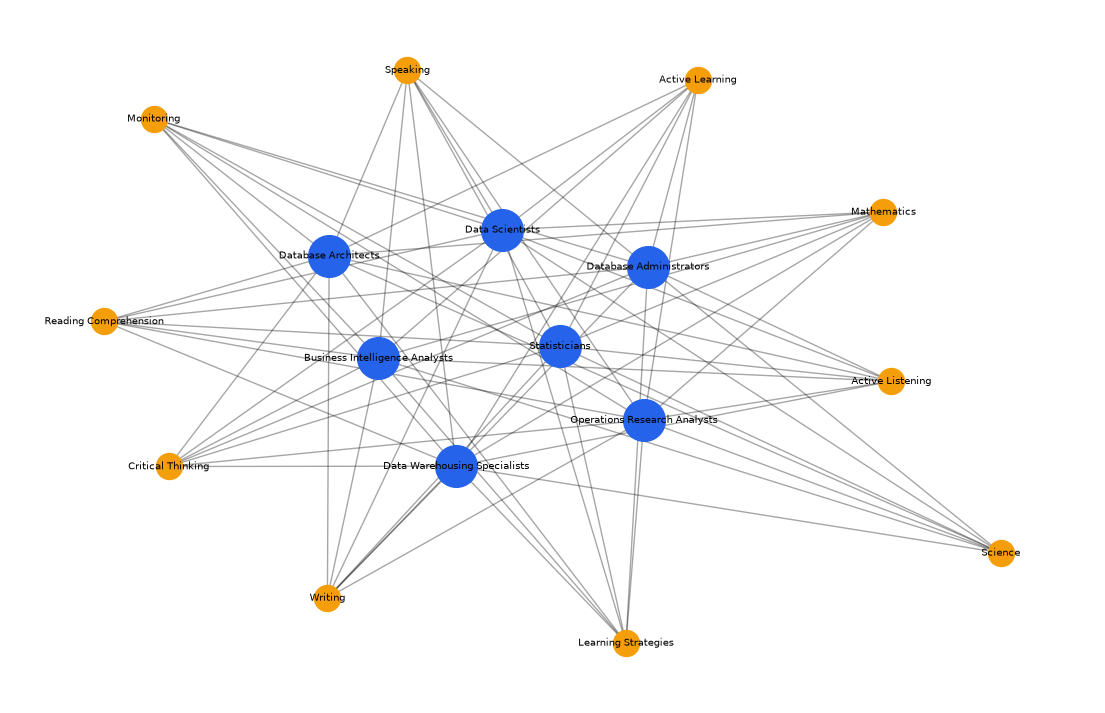

In [9]:
import networkx as nx
import matplotlib.pyplot as plt

domain = 'essential_skills'
matrix = main_matrices[domain]
G = nx.Graph()
selected = [x for x in CONFIG['core'] if x in matrix.index]
for code in selected:
    G.add_node(code, kind='occupation', label=occupation_names.get(code, code))
    for element, weight in matrix.loc[code].nlargest(10).items():
        node = 'competency:' + element
        G.add_node(node, kind='competency', label=element_names.get(element, element))
        G.add_edge(code, node, weight=float(weight))
pos = nx.spring_layout(G, seed=42, k=1.4)
plt.figure(figsize=(14, 9))
nx.draw_networkx_nodes(G, pos, nodelist=selected, node_color='#2563eb', node_size=900)
comp_nodes = [n for n in G if n not in selected]
nx.draw_networkx_nodes(G, pos, nodelist=comp_nodes, node_color='#f59e0b', node_size=350)
nx.draw_networkx_edges(G, pos, alpha=.35)
nx.draw_networkx_labels(G, pos, labels={n: G.nodes[n]['label'] for n in G}, font_size=7)
plt.axis('off'); plt.show()

In [10]:
# Tabel jarak/bobot competency ke setiap occupation
display(Markdown('## 8. Tabel Jarak Competency ke Occupation'))

domain = 'essential_skills'
matrix = main_matrices[domain]
selected = [x for x in CONFIG['core'] if x in matrix.index]

# Buat tabel dengan baris = competency, kolom = occupation
distance_table = []
for element in matrix.columns:
    row = {
        'competency_name': element_names.get(element, 'N/A'),
        'competency_id': element,
        'description': element_descriptions.get(element, '')[:100]  # 100 char preview
    }
    for occ_code in selected:
        weight = matrix.loc[occ_code, element]
        occ_name = occupation_names.get(occ_code, 'N/A')
        row[f'{occ_name} [{occ_code}]'] = weight
    distance_table.append(row)

distance_df = pd.DataFrame(distance_table)
# Sort by max distance across occupations (descending)
distance_df['max_weight'] = distance_df.iloc[:, 3:].max(axis=1)
distance_df = distance_df.sort_values('max_weight', ascending=False).drop('max_weight', axis=1)

display(distance_df)

## 8. Tabel Jarak Competency ke Occupation

,competency_name,competency_id,description,Data Scientists [15-2051.00],Business Intelligence Analysts [15-2051.01],Database Administrators [15-1242.00],Database Architects [15-1243.00],Data Warehousing Specialists [15-1243.01],Operations Research Analysts [15-2031.00],Statisticians [15-2041.00]
4,Mathematics,2.A.1.e,Using mathematics to solve problems.,0.8450,0.6250,0.5000,0.5000,0.5000,0.8750,0.9700
6,Critical Thinking,2.A.2.a,Using logic and reasoning to identify the stre...,0.8125,0.7200,0.7200,0.7200,0.7200,0.7500,0.7500
1,Active Listening,2.A.1.b,Giving full attention to what other people are...,0.6250,0.7200,0.6875,0.6250,0.6250,0.7500,0.7200
0,Reading Comprehension,2.A.1.a,Understanding written sentences and paragraphs...,0.7200,0.7500,0.6875,0.7200,0.7200,0.7500,0.7500
3,Speaking,2.A.1.d,Talking to others to convey information effect...,0.6550,0.7200,0.5950,0.6250,0.5950,0.7500,0.7200
2,Writing,2.A.1.c,Communicating effectively in writing as approp...,0.6250,0.6875,0.5625,0.5300,0.5625,0.7500,0.6875
7,Active Learning,2.A.2.b,Understanding the implications of new informat...,0.6550,0.7200,0.6250,0.5625,0.5000,0.7200,0.6875
5,Science,2.A.1.f,Using scientific rules and methods to solve pr...,0.3750,0.1550,0.2500,0.2200,0.2200,0.5625,0.6250
9,Monitoring,2.A.2.d,"Monitoring/Assessing performance of yourself, ...",0.5625,0.5300,0.5625,0.5300,0.4700,0.4700,0.5000
8,Learning Strategies,2.A.2.c,Selecting and using training/instructional met...,0.4375,0.5000,0.5000,0.4700,0.4050,0.5000,0.5300


## Kesimpulan

Yang dihitung bukan sekadar “kode mana yang dekat”. Kita membandingkan profil kemampuan pekerjaan: nama occupation menjelaskan objeknya, nama dan deskripsi elemen menjelaskan kompetensinya, sedangkan kode menjaga keterlacakan dan reproducibility.